In [1]:
# 1. Install GeoPandas (Colab does not have it by default)
!pip install geopandas mapclassify

# 2. Unzip the shapefile boundary zip file
!unzip -q bgd_admin_boundaries.shp.zip


In [6]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
from scipy.interpolate import griddata
from shapely.geometry import Point

# --- Colab Specific Paths ---
SHAPEFILE_PATH = "/content/bgd_admin3.shp"
POP_FILE = "/content/Dhaka_Thana_Population_2022.csv"
OUTPUT_HTML = "/content/Dhaka_Thana_Risk_Map.html"

print("[*] Starting Week 6 Spatial Interpolation & Mapping in Colab...")

# 1. Load the shapefile and population data
print("[*] Loading ADM3 Shapefile...")
gdf = gpd.read_file(SHAPEFILE_PATH)

# Try to identify correct column names dynamically
adm2_col = next((c for c in gdf.columns if 'ADM2' in c.upper()), None)
adm3_col = next((c for c in gdf.columns if 'ADM3' in c.upper()), None)

if not adm2_col or not adm3_col:
    raise KeyError(f"Could not find ADM2 or ADM3 columns. Found: {gdf.columns.tolist()}")

# Filter for Dhaka District
print(f"[*] Filtering shapefile for Dhaka District using column: {adm2_col}...")
gdf_dhaka = gdf[gdf[adm2_col].str.contains('Dhaka', case=False, na=False)].copy()

if gdf_dhaka.empty:
    print(f"[!] Dhaka district not found in {adm2_col}. Falling back to population file filter...")
    df_pop = pd.read_csv(POP_FILE)
    thanas = df_pop['ADM3_NAME'].unique()
    gdf_dhaka = gdf[gdf[adm3_col].isin(thanas)].copy()

# Standardize column names
gdf_dhaka = gdf_dhaka.rename(columns={adm3_col: 'ADM3_NAME'})

# --- FIX: Remove or convert Timestamp columns before Folium processing ---
for col in gdf_dhaka.columns:
    if pd.api.types.is_datetime64_any_dtype(gdf_dhaka[col]):
        gdf_dhaka[col] = gdf_dhaka[col].astype(str)

print(f"    Loaded {len(gdf_dhaka)} Thana polygons.")

# Ensure CRS is EPSG:4326 (WGS 84)
gdf_dhaka = gdf_dhaka.to_crs(epsg=4326)

# 2. Define the monitoring stations
stations = {
    'US Consulate (Gulshan)': {'lat': 23.7979, 'lon': 90.4143, 'pred_pm25': 234.0},
    'Darus Salam (CAMS-1)': {'lat': 23.7802, 'lon': 90.3541, 'pred_pm25': 255.0},
    'Parliament Area (CAMS-2)': {'lat': 23.7621, 'lon': 90.3785, 'pred_pm25': 210.0},
    'BARC (CAMS-3)': {'lat': 23.7500, 'lon': 90.3900, 'pred_pm25': 225.0}
}

station_df = pd.DataFrame.from_dict(stations, orient='index')
station_points = np.array(list(zip(station_df['lon'], station_df['lat'])))
station_values = station_df['pred_pm25'].values

# 3. Create a dense grid
xmin, ymin, xmax, ymax = gdf_dhaka.total_bounds
grid_x, grid_y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]

# Interpolation
grid_z = griddata(station_points, station_values, (grid_x, grid_y), method='linear')
grid_z_nearest = griddata(station_points, station_values, (grid_x, grid_y), method='nearest')
grid_z = np.where(np.isnan(grid_z), grid_z_nearest, grid_z)

# 4. Convert grid points to GeoDataFrame
grid_points = [Point(x, y) for x, y in zip(grid_x.ravel(), grid_y.ravel())]
grid_values = grid_z.ravel()
gdf_grid = gpd.GeoDataFrame({'pred_pm25': grid_values}, geometry=grid_points, crs="EPSG:4326")

# 5. Spatial Join and Zonal Means
print("[*] Performing spatial interpolation and zonal averaging...")
joined = gpd.sjoin(gdf_grid, gdf_dhaka, how='inner', predicate='within')
thana_means = joined.groupby('ADM3_NAME')['pred_pm25'].mean().reset_index()

# Merge back
gdf_dhaka = gdf_dhaka.merge(thana_means, on='ADM3_NAME', how='left')

# Fallback for Thanas with no points
for idx, row in gdf_dhaka.iterrows():
    if pd.isna(row['pred_pm25']):
        centroid = row['geometry'].centroid
        distances = station_df.apply(lambda r: centroid.distance(Point(r['lon'], r['lat'])), axis=1)
        nearest_station = distances.idxmin()
        gdf_dhaka.at[idx, 'pred_pm25'] = stations[nearest_station]['pred_pm25']

# 6. Folium Map
print("[*] Building Folium Choropleth map...")
m = folium.Map(location=[23.7771, 90.3994], zoom_start=12, tiles='CartoDB positron')

thresholds = [150.0, 180.0, 200.0, 220.0, 240.0, 260.0]

folium.Choropleth(
    geo_data=gdf_dhaka,
    name='Choropleth',
    data=gdf_dhaka,
    columns=['ADM3_NAME', 'pred_pm25'],
    key_on='feature.properties.ADM3_NAME',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Predicted PM2.5 (µg/m³)',
    bins=thresholds
).add_to(m)

for name, data in stations.items():
    folium.Marker(
        location=[data['lat'], data['lon']],
        popup=f"<b>{name}</b><br>PM2.5: {data['pred_pm25']}",
        icon=folium.Icon(color='red')
    ).add_to(m)

m.save(OUTPUT_HTML)
print(f"[+] Map saved at {OUTPUT_HTML}!")

[*] Starting Week 6 Spatial Interpolation & Mapping in Colab...
[*] Loading ADM3 Shapefile...
[*] Filtering shapefile for Dhaka District using column: adm2_name...
    Loaded 7 Thana polygons.
[*] Performing spatial interpolation and zonal averaging...
[*] Building Folium Choropleth map...
[+] Map saved at /content/Dhaka_Thana_Risk_Map.html!


In [7]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
from scipy.interpolate import griddata
from shapely.geometry import Point

# --- Colab Specific Paths ---
SHAPEFILE_PATH = "/content/bgd_admin3.shp"
POP_FILE = "/content/Dhaka_Thana_Population_2022.csv"
OUTPUT_HTML = "/content/Dhaka_Thana_Risk_Map.html"

print("[*] Starting Week 6 Spatial Interpolation & Mapping in Colab...")

# 1. Load the shapefile and population data
print("[*] Loading ADM3 Shapefile...")
gdf = gpd.read_file(SHAPEFILE_PATH)

# Try to identify correct column names dynamically
adm2_col = next((c for c in gdf.columns if 'ADM2' in c.upper()), None)
adm3_col = next((c for c in gdf.columns if 'ADM3' in c.upper()), None)

if not adm2_col or not adm3_col:
    raise KeyError(f"Could not find ADM2 or ADM3 columns. Found: {gdf.columns.tolist()}")

# Filter for Dhaka District
print(f"[*] Filtering shapefile for Dhaka District using column: {adm2_col}...")
gdf_dhaka = gdf[gdf[adm2_col].str.contains('Dhaka', case=False, na=False)].copy()

if gdf_dhaka.empty:
    print(f"[!] Dhaka district not found in {adm2_col}. Falling back to population file filter...")
    df_pop = pd.read_csv(POP_FILE)
    thanas = df_pop['ADM3_NAME'].unique()
    gdf_dhaka = gdf[gdf[adm3_col].isin(thanas)].copy()

# Standardize column names
gdf_dhaka = gdf_dhaka.rename(columns={adm3_col: 'ADM3_NAME'})

# --- FIX: Remove or convert Timestamp columns before Folium processing ---
for col in gdf_dhaka.columns:
    if pd.api.types.is_datetime64_any_dtype(gdf_dhaka[col]):
        gdf_dhaka[col] = gdf_dhaka[col].astype(str)

print(f"    Loaded {len(gdf_dhaka)} Thana polygons.")

# Ensure CRS is EPSG:4326 (WGS 84)
gdf_dhaka = gdf_dhaka.to_crs(epsg=4326)

# 2. Define the monitoring stations
stations = {
    'US Consulate (Gulshan)': {'lat': 23.7979, 'lon': 90.4143, 'pred_pm25': 234.0},
    'Darus Salam (CAMS-1)': {'lat': 23.7802, 'lon': 90.3541, 'pred_pm25': 255.0},
    'Parliament Area (CAMS-2)': {'lat': 23.7621, 'lon': 90.3785, 'pred_pm25': 210.0},
    'BARC (CAMS-3)': {'lat': 23.7500, 'lon': 90.3900, 'pred_pm25': 225.0}
}

station_df = pd.DataFrame.from_dict(stations, orient='index')
station_points = np.array(list(zip(station_df['lon'], station_df['lat'])))
station_values = station_df['pred_pm25'].values

# 3. Create a dense grid
xmin, ymin, xmax, ymax = gdf_dhaka.total_bounds
grid_x, grid_y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]

# Interpolation
grid_z = griddata(station_points, station_values, (grid_x, grid_y), method='linear')
grid_z_nearest = griddata(station_points, station_values, (grid_x, grid_y), method='nearest')
grid_z = np.where(np.isnan(grid_z), grid_z_nearest, grid_z)

# 4. Convert grid points to GeoDataFrame
grid_points = [Point(x, y) for x, y in zip(grid_x.ravel(), grid_y.ravel())]
grid_values = grid_z.ravel()
gdf_grid = gpd.GeoDataFrame({'pred_pm25': grid_values}, geometry=grid_points, crs="EPSG:4326")

# 5. Spatial Join and Zonal Means
print("[*] Performing spatial interpolation and zonal averaging...")
joined = gpd.sjoin(gdf_grid, gdf_dhaka, how='inner', predicate='within')
thana_means = joined.groupby('ADM3_NAME')['pred_pm25'].mean().reset_index()

# Merge back
gdf_dhaka = gdf_dhaka.merge(thana_means, on='ADM3_NAME', how='left')

# Fallback for Thanas with no points
for idx, row in gdf_dhaka.iterrows():
    if pd.isna(row['pred_pm25']):
        centroid = row['geometry'].centroid
        distances = station_df.apply(lambda r: centroid.distance(Point(r['lon'], r['lat'])), axis=1)
        nearest_station = distances.idxmin()
        gdf_dhaka.at[idx, 'pred_pm25'] = stations[nearest_station]['pred_pm25']

# 6. Folium Map
print("[*] Building Folium Choropleth map...")
m = folium.Map(location=[23.7771, 90.3994], zoom_start=12, tiles='CartoDB positron')

thresholds = [150.0, 180.0, 200.0, 220.0, 240.0, 260.0]

folium.Choropleth(
    geo_data=gdf_dhaka,
    name='Choropleth',
    data=gdf_dhaka,
    columns=['ADM3_NAME', 'pred_pm25'],
    key_on='feature.properties.ADM3_NAME',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Predicted PM2.5 (µg/m³)',
    bins=thresholds
).add_to(m)

for name, data in stations.items():
    folium.Marker(
        location=[data['lat'], data['lon']],
        popup=f"<b>{name}</b><br>PM2.5: {data['pred_pm25']}",
        icon=folium.Icon(color='red')
    ).add_to(m)

m.save(OUTPUT_HTML)
print(f"[+] Map saved at {OUTPUT_HTML}!")

[*] Starting Week 6 Spatial Interpolation & Mapping in Colab...
[*] Loading ADM3 Shapefile...
[*] Filtering shapefile for Dhaka District using column: adm2_name...
    Loaded 7 Thana polygons.
[*] Performing spatial interpolation and zonal averaging...
[*] Building Folium Choropleth map...
[+] Map saved at /content/Dhaka_Thana_Risk_Map.html!


In [8]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import folium
from scipy.interpolate import griddata
from shapely.geometry import Point

# --- Colab Specific Paths ---
SHAPEFILE_PATH = "/content/bgd_admin3.shp"
POP_FILE = "/content/Dhaka_Thana_Population_2022.csv"
OUTPUT_HTML = "/content/Dhaka_Thana_Risk_Map.html"

print("[*] Starting Week 6 Spatial Interpolation & Mapping in Colab...")

# 1. Load the shapefile and population data
print("[*] Loading ADM3 Shapefile...")
gdf = gpd.read_file(SHAPEFILE_PATH)

# Try to identify correct column names dynamically
adm2_col = next((c for c in gdf.columns if 'ADM2' in c.upper()), None)
adm3_col = next((c for c in gdf.columns if 'ADM3' in c.upper()), None)

if not adm2_col or not adm3_col:
    raise KeyError(f"Could not find ADM2 or ADM3 columns. Found: {gdf.columns.tolist()}")

# Filter for Dhaka District
print(f"[*] Filtering shapefile for Dhaka District using column: {adm2_col}...")
gdf_dhaka = gdf[gdf[adm2_col].str.contains('Dhaka', case=False, na=False)].copy()

if gdf_dhaka.empty:
    print(f"[!] Dhaka district not found in {adm2_col}. Falling back to population file filter...")
    df_pop = pd.read_csv(POP_FILE)
    thanas = df_pop['ADM3_NAME'].unique()
    gdf_dhaka = gdf[gdf[adm3_col].isin(thanas)].copy()

# Standardize column names
gdf_dhaka = gdf_dhaka.rename(columns={adm3_col: 'ADM3_NAME'})

# --- FIX: Remove or convert Timestamp columns before Folium processing ---
for col in gdf_dhaka.columns:
    if pd.api.types.is_datetime64_any_dtype(gdf_dhaka[col]):
        gdf_dhaka[col] = gdf_dhaka[col].astype(str)

print(f"    Loaded {len(gdf_dhaka)} Thana polygons.")

# Ensure CRS is EPSG:4326 (WGS 84)
gdf_dhaka = gdf_dhaka.to_crs(epsg=4326)

# 2. Define the monitoring stations
stations = {
    'US Consulate (Gulshan)': {'lat': 23.7979, 'lon': 90.4143, 'pred_pm25': 234.0},
    'Darus Salam (CAMS-1)': {'lat': 23.7802, 'lon': 90.3541, 'pred_pm25': 255.0},
    'Parliament Area (CAMS-2)': {'lat': 23.7621, 'lon': 90.3785, 'pred_pm25': 210.0},
    'BARC (CAMS-3)': {'lat': 23.7500, 'lon': 90.3900, 'pred_pm25': 225.0}
}

station_df = pd.DataFrame.from_dict(stations, orient='index')
station_points = np.array(list(zip(station_df['lon'], station_df['lat'])))
station_values = station_df['pred_pm25'].values

# 3. Create a dense grid
xmin, ymin, xmax, ymax = gdf_dhaka.total_bounds
grid_x, grid_y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]

# Interpolation
grid_z = griddata(station_points, station_values, (grid_x, grid_y), method='linear')
grid_z_nearest = griddata(station_points, station_values, (grid_x, grid_y), method='nearest')
grid_z = np.where(np.isnan(grid_z), grid_z_nearest, grid_z)

# 4. Convert grid points to GeoDataFrame
grid_points = [Point(x, y) for x, y in zip(grid_x.ravel(), grid_y.ravel())]
grid_values = grid_z.ravel()
gdf_grid = gpd.GeoDataFrame({'pred_pm25': grid_values}, geometry=grid_points, crs="EPSG:4326")

# 5. Spatial Join and Zonal Means
print("[*] Performing spatial interpolation and zonal averaging...")
joined = gpd.sjoin(gdf_grid, gdf_dhaka, how='inner', predicate='within')
thana_means = joined.groupby('ADM3_NAME')['pred_pm25'].mean().reset_index()

# Merge back
gdf_dhaka = gdf_dhaka.merge(thana_means, on='ADM3_NAME', how='left')

# Fallback for Thanas with no points
for idx, row in gdf_dhaka.iterrows():
    if pd.isna(row['pred_pm25']):
        centroid = row['geometry'].centroid
        distances = station_df.apply(lambda r: centroid.distance(Point(r['lon'], r['lat'])), axis=1)
        nearest_station = distances.idxmin()
        gdf_dhaka.at[idx, 'pred_pm25'] = stations[nearest_station]['pred_pm25']

# 6. Folium Map
print("[*] Building Folium Choropleth map...")
m = folium.Map(location=[23.7771, 90.3994], zoom_start=12, tiles='CartoDB positron')

thresholds = [150.0, 180.0, 200.0, 220.0, 240.0, 260.0]

folium.Choropleth(
    geo_data=gdf_dhaka,
    name='Choropleth',
    data=gdf_dhaka,
    columns=['ADM3_NAME', 'pred_pm25'],
    key_on='feature.properties.ADM3_NAME',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Predicted PM2.5 (µg/m³)',
    bins=thresholds
).add_to(m)

for name, data in stations.items():
    folium.Marker(
        location=[data['lat'], data['lon']],
        popup=f"<b>{name}</b><br>PM2.5: {data['pred_pm25']}",
        icon=folium.Icon(color='red')
    ).add_to(m)

m.save(OUTPUT_HTML)
print(f"[+] Map saved at {OUTPUT_HTML}!")

[*] Starting Week 6 Spatial Interpolation & Mapping in Colab...
[*] Loading ADM3 Shapefile...
[*] Filtering shapefile for Dhaka District using column: adm2_name...
    Loaded 7 Thana polygons.
[*] Performing spatial interpolation and zonal averaging...
[*] Building Folium Choropleth map...
[+] Map saved at /content/Dhaka_Thana_Risk_Map.html!


### Displaying the Generated Risk Map
The code above saved the map to a file. Use the cell below to view the interactive map directly in this notebook.

In [12]:
import base64
from IPython.display import HTML

# Read the HTML file and encode it to base64 to bypass local connection restrictions
with open('Dhaka_Thana_Risk_Map.html', 'r', encoding='utf-8') as f:
    html_content = f.read()

# Create a data URI
b64_content = base64.b64encode(html_content.encode('utf-8')).decode('utf-8')
data_uri = f'data:text/html;base64,{b64_content}'

# Display using an IFrame with the data URI
display(HTML(f'<iframe src="{data_uri}" width="100%" height="600px" style="border:none;"></iframe>'))

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


### Summary Table
Here are the calculated average PM2.5 levels for each Thana (Administrative Level 3):

,ADM3_NAME,pred_pm25
0,Dhamrai,255.000000
3,Nawabganj,255.000000
1,Dohar,254.936742
4,Savar,254.823483
5,Dhaka North City Corporation,236.878857
2,Keraniganj,235.163265
6,Dhaka South City Corporation,226.210046


<Figure size 1000x600 with 0 Axes>

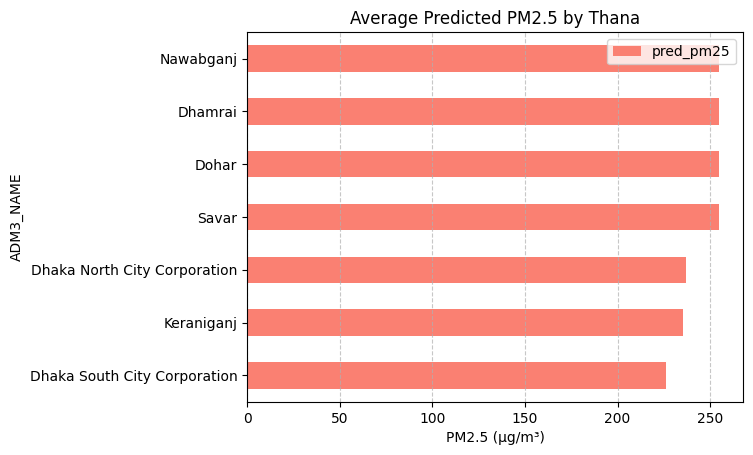

In [10]:
import matplotlib.pyplot as plt

# Display the numerical results
display(gdf_dhaka[['ADM3_NAME', 'pred_pm25']].sort_values(by='pred_pm25', ascending=False))

# Simple static bar chart for quick visualization
plt.figure(figsize=(10, 6))
gdf_dhaka.sort_values('pred_pm25').plot(kind='barh', x='ADM3_NAME', y='pred_pm25', color='salmon')
plt.title('Average Predicted PM2.5 by Thana')
plt.xlabel('PM2.5 (µg/m³)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()